In [ ]:
from pathlib import Path
import cv2
import pandas as pd

ruta_videos = Path("../data/raw")
videos = []

for video in ruta_videos.glob("*.mp4"):

    nombre = video.stem
    cap = cv2.VideoCapture(str(video))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    ancho = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    alto = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

    duracion = frames / fps if fps else 0
    videos.append({
        "video": nombre,
        "fps": round(fps,2),
        "frames": int(frames),
        "resolucion": f"{int(ancho)}x{int(alto)}",
        "duracion_seg": round(duracion,2)
    })

    cap.release()
df_videos = pd.DataFrame(videos)
df_videos

,video,fps,frames,resolucion,duracion_seg
0,V1_video1_normal,29.99,2340,576x1024,78.03
1,V1_video2_pocaluz,23.99,1477,576x1024,61.56
2,V2_video1_normal,29.99,2100,576x1024,70.02
3,V2_video2_lentes,29.98,1972,576x1024,65.77
4,V3_video1_normal,30.01,3734,848x478,124.43
5,V3_video2_lentes,30.01,3663,848x478,122.07
6,V4_video1_normal,29.30,1032,368x368,35.22
7,V4_video2_pocaluz,23.67,730,368x368,30.84
8,V5_video1_normal,29.96,1699,478x850,56.71
9,V5_video2_pocaluz,29.96,1156,478x850,38.58


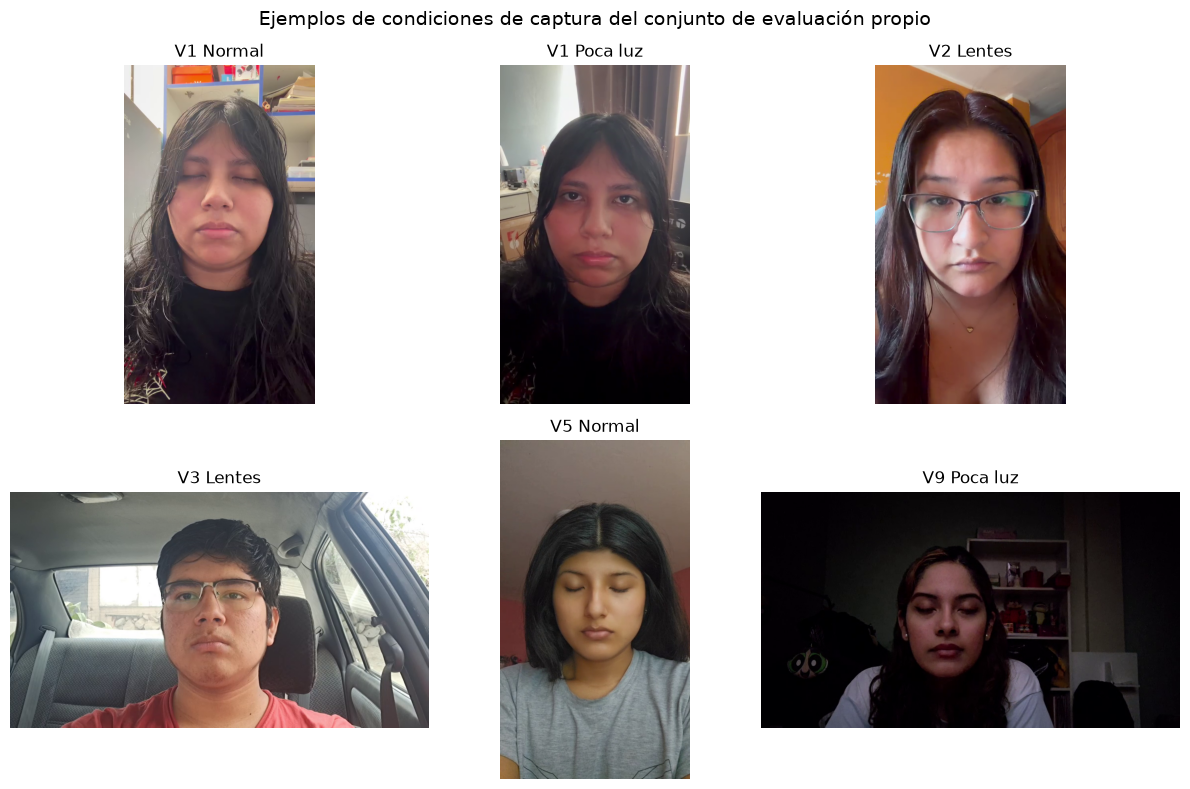

In [15]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Carpeta donde están tus videos
ruta_videos = Path("../data/raw")

# Videos que queremos mostrar
videos = [
    ("V1_video1_normal.mp4", "V1 Normal"),
    ("V1_video2_pocaluz.mp4", "V1 Poca luz"),
    ("V2_video2_lentes.mp4", "V2 Lentes"),
    ("V3_video2_lentes.mp4", "V3 Lentes"),
    ("V5_video1_normal.mp4", "V5 Normal"),
    ("V9_video2_pocaluz.mp4", "V9 Poca luz")
]

imagenes = []
for archivo, titulo in videos:
    ruta = ruta_videos / archivo
    cap = cv2.VideoCapture(str(ruta))
    # Obtener número total de frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Tomamos un frame del centro del video
    frame_medio = total_frames // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_medio)
    ret, frame = cap.read()

    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        imagenes.append((frame, titulo))
    cap.release()
    
# Crear figura 2x3
plt.figure(figsize=(12,8))

for i,(img,titulo) in enumerate(imagenes):
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(titulo, fontsize=12)
    plt.axis("off")

plt.suptitle(
    "Ejemplos de condiciones de captura del conjunto de evaluación propio",
    fontsize=14
)
plt.tight_layout()

# Guardar imagen para el informe
plt.savefig(
    "../results/fig_condiciones_evaluacion.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from pathlib import Path

ruta_xml = Path("../data/labeled")
xmls=list(ruta_xml.glob("*.xml"))

print("Cantidad XML:",len(xmls))
print(xmls[0])
print(open(xmls[0],encoding="utf-8").read()[:1000])

Cantidad XML: 36
..\data\labeled\V1_video1_normal_A.xml
<?xml version="1.0" encoding="utf-8"?>
<annotations>
  <version>1.1</version>
  <meta>
    <job>
      <id>4533141</id>
      <size>2340</size>
      <mode>interpolation</mode>
      <overlap>0</overlap>
      <bugtracker></bugtracker>
      <created>2026-09-30 21:18:02.279293+00:00</created>
      <updated>2026-09-30 22:04:58.689697+00:00</updated>
      <subset>default</subset>
      <start_frame>0</start_frame>
      <stop_frame>2339</stop_frame>
      <frame_filter></frame_filter>
      <segments>
        <segment>
          <id>4530415</id>
          <start>0</start>
          <stop>2339</stop>
          <url>https://app.cvat.ai/api/jobs/4533141/dataset/export/api/jobs/4533141</url>
        </segment>
      </segments>
      <owner>
        <username>Fioo11</username>
        <email>fiorellavilca200717@gmail.com</email>
      </owner>
      <assignee></assignee>
      <labels>
        <label>
          <name>cierre_ocular</na